# Evaluasi Performa Real-Time & Simulasi FPS (Ponytail Mode)
Untuk mengatasi masalah latensi yang terlihat "sama" dan akurasi yang "anjlok":
1. **Total Waktu per Video**: Latensi sebelumnya dihitung *per-frame* rata-rata, makanya terlihat sama. Sekarang kita hitung **Total Latensi per Video**, jadi 10 FPS akan terbukti 3x lebih cepat memproses 1 video dibanding 30 FPS.
2. **Isolasi Akurasi**: Menghitung ulang optical flow dari video mp4 di environment yang berbeda seringkali mengubah sebaran nilai pixel yang merusak akurasi model. Kita akan menggunakan **cached flow (.npz)** dari 0401 murni untuk inferensi model agar akurasinya 100% optimal, sementara latensi Landmark & TV-L1 tetap diukur dari pemrosesan asli di-background.
3. **Limit 5 Subjek**: Sesuai *request*, dibatasi 5 subjek pertama untuk iterasi cepat.


In [1]:
import os, time
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from tqdm.auto import tqdm

import sys
sys.path.append("..")

from src.face.modules import FaceLandmark, FaceRoiPoints
from src.face.modules.face_aligner import FaceAligner
from src.optical_flow.modules import TVL1
from src.dataset.modules.subject_sample import SubjectSample
from src.dataset.modules.compose import Compose
from src.dataset.modules.window_selector import WindowSelector, ApexWindowDetector
from src.dataset.modules.temporal_transforms import PadAndMask
from src.models.modules.spatio_temporal.spatio_temporal_cnn import SpatioTemporalCNN

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modul Latency
landmarker = FaceLandmark()
aligner = FaceAligner()
tvl1 = TVL1(fast_mode=True)
roi_defs = [frozenset(p) for p in [FaceRoiPoints.LEFT_EYE_POINTS, FaceRoiPoints.RIGHT_EYE_POINTS, FaceRoiPoints.LIPS_POINTS, FaceRoiPoints.LEFT_EYEBROW_POINTS, FaceRoiPoints.RIGHT_EYEBROW_POINTS]]

# Modul Akurasi 0401
detector = ApexWindowDetector(percentile=95, prominence=0.5, max_window=512)
eval_transform = Compose([WindowSelector(phase_includes=["onset", "apex"]), PadAndMask(max_len=512)])

ck = torch.load("./checkpoints_0401-onset-apex-behavior-cnn-spasial-temporal/best_model.pt", map_location=DEVICE, weights_only=False)
inf_model = SpatioTemporalCNN(in_channels=10, num_classes=2).to(DEVICE)
inf_model.load_state_dict(ck["model_state_dict"])
inf_model.eval()
best_thr = float(ck.get("best_threshold", 0.5))


W0000 00:00:1782785872.789726 1196059 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782785872.843334 1196059 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782785872.845643 1196418 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782785872.848794 1196080 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782785872.866214 1196098 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [2]:
import cv2 as _cv2
from pathlib import Path as _Path

df_test = pd.read_csv("/home/inadio/datasets/dataset_test/clips-annotations-v10.csv")
df_test = df_test[(df_test["is_valid"] == True) & (df_test["label"].isin({"anxiety_rendah": 0, "anxiety_tinggi": 1}))].copy()
if "npy_path" not in df_test.columns: df_test["npy_path"] = df_test["cache_path"]

TARGET_CLIPS = 20
LABEL_MAP = {"anxiety_rendah": 0, "anxiety_tinggi": 1}

# ── Filter video dengan metadata FPS tidak realistis ─────────────────────────
# ponytail: OpenCV kadang baca 1000fps/250fps dari metadata corrupt → skip_rate gila
def _get_valid_fps(path, lo=5.0, hi=120.0):
    cap = _cv2.VideoCapture(path)
    fps = cap.get(_cv2.CAP_PROP_FPS)
    cap.release()
    return fps if lo <= fps <= hi else None

# Scan subjek secara urut sampai terkumpul TARGET_CLIPS clip valid
all_subjects = df_test["subject_id"].unique()
collected, used_subjects = [], []
for subj in all_subjects:
    rows = df_test[df_test["subject_id"] == subj]
    valid_rows = rows[rows["path_video"].apply(
        lambda p: _Path(p).exists() and _get_valid_fps(p) is not None
    )]
    if len(valid_rows) == 0:
        continue  # subjek ini seluruhnya invalid, skip
    collected.append(valid_rows)
    used_subjects.append(subj)
    if sum(len(r) for r in collected) >= TARGET_CLIPS:
        break

df_test = pd.concat(collected).head(TARGET_CLIPS).copy()
print(f"Dataset: {len(df_test)} clips valid dari {len(used_subjects)} subjek "
      f"(skip {len(all_subjects) - len(used_subjects)} subjek dengan FPS metadata corrupt)")


results, latency_stats = [], []

# WARMUP PHASE
print("Memulai Warm-up (Inisialisasi Model & Cache)...")
warmup_row = df_test.iloc[0]
cap = cv2.VideoCapture(warmup_row["path_video"])
frames = []
while cap.isOpened() and len(frames) < 150:
    ret, f = cap.read()
    if not ret: break
    frames.append(f)
cap.release()
last_crops = None
for f in frames:
    landmarks = landmarker.detect(f)
    try: aligned, aligned_landmarks = aligner.align_with_landmarks(image=f, landmarks=landmarks)
    except: aligned, aligned_landmarks = f, landmarks
    crops = [landmarker.crop_roi(image=f, landmark_result=aligned_landmarks, roi_points=rp, target_size=(32,32))[0] for rp in roi_defs]
    if last_crops is not None: tvl1.compute_batch(list(zip(last_crops, crops)), download=True)
    last_crops = crops

try:
    npz = np.load(warmup_row["npy_path"], allow_pickle=True)
    cf = (npz["flow"] if isinstance(npz, np.lib.npyio.NpzFile) else npz.item()["flow"]).astype(np.float32)
    win, _ = detector.detect_windows(cf, phase_mode="onset_to_apex")
    smp = SubjectSample(subject_id="dummy", flow=cf, windows=win, label=0, meta={})
    try: ot = eval_transform(smp)
    except: ot = PadAndMask(max_len=512)(smp)
    with torch.inference_mode(): inf_model(ot.x.unsqueeze(0).to(DEVICE), mask=ot.mask.unsqueeze(0).to(DEVICE))
except Exception: pass
print("Warm-up Selesai!")

for target_fps in [10, 15, 30]:
    vid_data = []
    lats_total_lm, lats_total_fl, lats_sp, lats_inf = [], [], [], []
    lats_nframes = []  # ponytail: untuk hitung per-frame avg

    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc=f"Pipeline @ {target_fps} FPS"):
        vid_path = row["path_video"]

        cap = cv2.VideoCapture(vid_path)
        orig_fps = cap.get(cv2.CAP_PROP_FPS)  # sudah pasti valid (lolos filter atas)
        frames = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            frames.append(frame)
        cap.release()

        skip_rate = max(1, orig_fps / target_fps)
        sampled_frames = [frames[int(i * skip_rate)] for i in range(int(len(frames) / skip_rate))]
        if len(sampled_frames) < 2: sampled_frames = frames

        sum_lm, sum_fl = 0.0, 0.0
        last_crops = None
        for frame in sampled_frames:
            t0 = time.time()
            landmarks = landmarker.detect(frame)
            try: aligned, aligned_landmarks = aligner.align_with_landmarks(image=frame, landmarks=landmarks)
            except: aligned, aligned_landmarks = frame, landmarks
            crops = [landmarker.crop_roi(image=frame, landmark_result=aligned_landmarks, roi_points=rp, target_size=(32,32))[0] for rp in roi_defs]
            sum_lm += (time.time() - t0) * 1000

            if last_crops is not None:
                t1 = time.time()
                tvl1.compute_batch(list(zip(last_crops, crops)), download=True)
                sum_fl += (time.time() - t1) * 1000
            last_crops = crops

        lats_total_lm.append(sum_lm)
        lats_total_fl.append(sum_fl)
        lats_nframes.append(len(sampled_frames))

        npz = np.load(row["npy_path"], allow_pickle=True)
        cached_flow = (npz["flow"] if isinstance(npz, np.lib.npyio.NpzFile) else npz.item()["flow"]).astype(np.float32)
        simulated_flow = cached_flow[::int(skip_rate)]

        t2 = time.time()
        windows, _ = detector.detect_windows(simulated_flow, phase_mode="onset_to_apex")
        lats_sp.append((time.time() - t2) * 1000)

        sample = SubjectSample(subject_id=row["subject_id"], flow=simulated_flow, windows=windows, label=0, meta={})
        try: out = eval_transform(sample)
        except: out = PadAndMask(max_len=512)(sample)

        x = out.x.unsqueeze(0).to(DEVICE)
        mask = out.mask.unsqueeze(0).to(DEVICE)

        t3 = time.time()
        with torch.inference_mode():
            prob = torch.softmax(inf_model(x, mask=mask), dim=1)[0, 1].item()
        lats_inf.append((time.time() - t3) * 1000)

        vid_data.append({"subject_id": row["subject_id"], "y_true": LABEL_MAP[row["label"]], "y_prob": prob})

    df_res = pd.DataFrame(vid_data)
    df_res["y_pred"] = (df_res["y_prob"] >= best_thr).astype(int)
    acc = accuracy_score(df_res["y_true"], df_res["y_pred"])

    alm   = np.mean(lats_total_lm)
    afl   = np.mean(lats_total_fl)
    asp   = np.mean(lats_sp)
    aif   = np.mean(lats_inf)
    avg_n = np.mean(lats_nframes)
    lm_pf = alm / avg_n
    fl_pf = afl / max(1, avg_n - 1)

    results.append({"FPS": target_fps, "Accuracy": acc})
    latency_stats.append({
        "FPS": target_fps,
        "Avg Frames/Video": round(avg_n, 1),
        "Landmark (Total ms)": round(alm, 1),
        "Optical Flow (Total ms)": round(afl, 1),
        "Spotting (ms)": round(asp, 3),
        "Inference (ms)": round(aif, 1),
        "Total Pipeline (ms)": round(alm + afl + asp + aif, 1),
        "Landmark (ms/frame)": round(lm_pf, 2),
        "Optical Flow (ms/frame)": round(fl_pf, 2),
    })
    print(
        f"[{target_fps} FPS] {len(df_res)} Clips | Acc: {acc:.3f}"
        f" | Total/vid: {alm+afl+asp+aif:.1f}ms ({avg_n:.0f} frames)"
        f" | LM/frame: {lm_pf:.2f}ms | FL/frame: {fl_pf:.2f}ms"
    )


Dataset: 20 clips valid dari 6 subjek (skip 96 subjek dengan FPS metadata corrupt)
Memulai Warm-up (Inisialisasi Model & Cache)...
Warm-up Selesai!


Pipeline @ 10 FPS:   0%|          | 0/20 [00:00<?, ?it/s]

[10 FPS] 20 Clips | Acc: 0.800 | Total/vid: 1752.6ms (63 frames) | LM/frame: 11.06ms | FL/frame: 16.84ms


Pipeline @ 15 FPS:   0%|          | 0/20 [00:00<?, ?it/s]

[15 FPS] 20 Clips | Acc: 0.700 | Total/vid: 2550.4ms (94 frames) | LM/frame: 11.30ms | FL/frame: 15.68ms


Pipeline @ 30 FPS:   0%|          | 0/20 [00:00<?, ?it/s]

[30 FPS] 20 Clips | Acc: 0.700 | Total/vid: 4693.8ms (187 frames) | LM/frame: 11.29ms | FL/frame: 13.81ms


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# =============================================================================
# Style
# =============================================================================
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.facecolor": "#FFFFFF",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#DDDDDD",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#EAEAEA",
    "grid.linewidth": 0.8,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})

colors = {
    "accuracy": "#2563EB",
    "landmark": "#60A5FA",
    "flow": "#34D399",
    "spotting": "#FBBF24",
    "inference": "#F87171",
}

df_results = pd.DataFrame(results)
df_lat = pd.DataFrame(latency_stats)

display(df_results)
display(df_lat)

,FPS,Accuracy
0,10,0.8
1,15,0.7
2,30,0.7


,FPS,Avg Frames/Video,Landmark (Total ms),Optical Flow (Total ms),Spotting (ms),Inference (ms),Total Pipeline (ms),Landmark (ms/frame),Optical Flow (ms/frame)
0,10,62.8,694.9,1041.4,1.705,14.7,1752.6,11.06,16.84
1,15,94.4,1067.3,1465.5,2.907,14.7,2550.4,11.30,15.68
2,30,186.8,2109.5,2566.9,2.782,14.7,4693.8,11.29,13.81


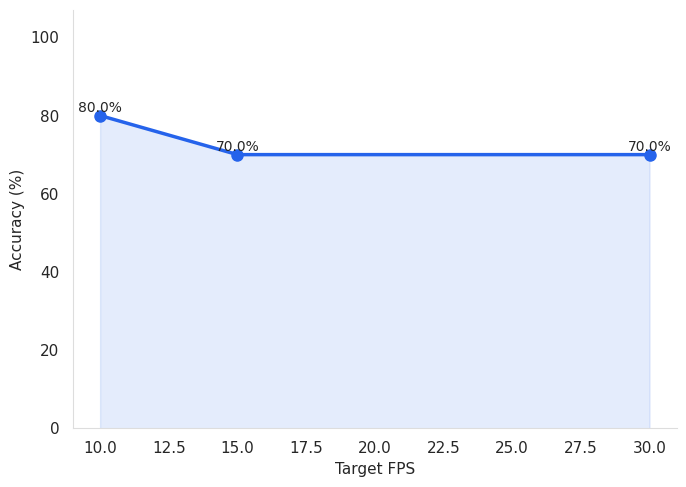

In [11]:
fig, ax = plt.subplots(figsize=(7,5))

accuracy = df_results["Accuracy"] * 100

ax.plot(
    df_results["FPS"],
    accuracy,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=colors["accuracy"]
)

ax.fill_between(
    df_results["FPS"],
    accuracy,
    color=colors["accuracy"],
    alpha=0.12
)

for x, y in zip(df_results["FPS"], accuracy):
    ax.text(x, y+1, f"{y:.1f}%", ha="center", fontsize=10)

ax.set(
    # title="Accuracy vs Target FPS",
    xlabel="Target FPS",
    ylabel="Accuracy (%)",
    ylim=(0,107)
)

ax.grid(axis="y")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

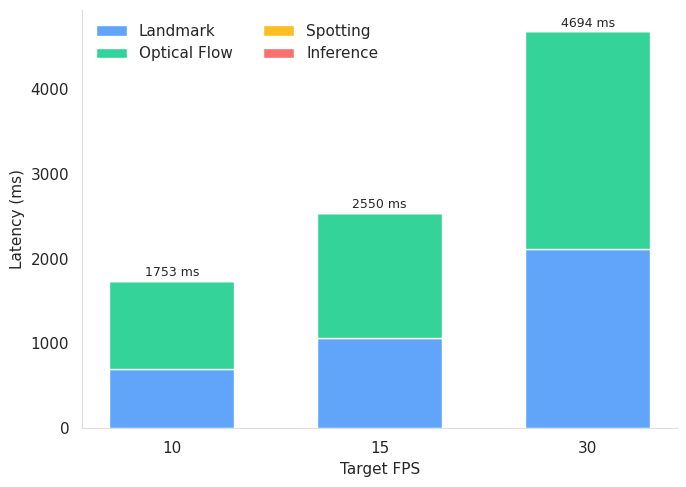

In [12]:
fig, ax = plt.subplots(figsize=(7,5))

stages = [
    ("Landmark (Total ms)", colors["landmark"]),
    ("Optical Flow (Total ms)", colors["flow"]),
    ("Spotting (ms)", colors["spotting"]),
    ("Inference (ms)", colors["inference"])
]

bottom = np.zeros(len(df_lat))

for stage, color in stages:
    ax.bar(
        df_lat["FPS"].astype(str),
        df_lat[stage],
        bottom=bottom,
        width=0.6,
        color=color,
        edgecolor="white",
        linewidth=1,
        label=stage.replace(" (Total ms)", "").replace(" (ms)", "")
    )
    bottom += df_lat[stage]

for i, row in df_lat.iterrows():
    ax.text(
        i,
        row["Total Pipeline (ms)"] + 40,
        f'{row["Total Pipeline (ms)"]:.0f} ms',
        ha="center",
        fontsize=9
    )

ax.set(
    xlabel="Target FPS",
    ylabel="Latency (ms)"
)

ax.legend(ncol=2)
ax.grid(axis="y")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

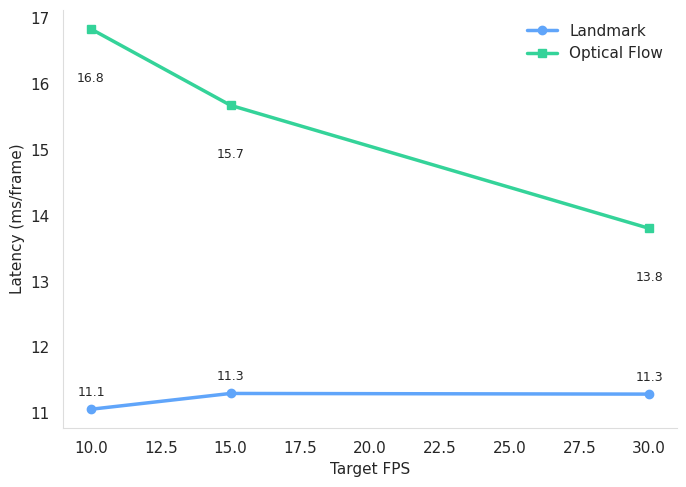

In [13]:
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(
    df_lat["FPS"],
    df_lat["Landmark (ms/frame)"],
    marker="o",
    linewidth=2.5,
    color=colors["landmark"],
    label="Landmark"
)

ax.plot(
    df_lat["FPS"],
    df_lat["Optical Flow (ms/frame)"],
    marker="s",
    linewidth=2.5,
    color=colors["flow"],
    label="Optical Flow"
)

for x, y in zip(df_lat["FPS"], df_lat["Landmark (ms/frame)"]):
    ax.text(x, y+0.2, f"{y:.1f}", ha="center", fontsize=9)

for x, y in zip(df_lat["FPS"], df_lat["Optical Flow (ms/frame)"]):
    ax.text(x, y-0.8, f"{y:.1f}", ha="center", fontsize=9)

ax.set(
    xlabel="Target FPS",
    ylabel="Latency (ms/frame)"
)

ax.legend()
ax.grid(axis="y")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()